## Schelling's Segregation Model - ABM 101

**How to use this notebook.** Read top to bottom and run each cell. The model is built in four
layers, each in its own class, so you can swap any one layer out without affecting the others:

| Layer | Class | Responsibility |
|---|---|---|
| Agent | `Household` | *who* acts = attributes and decision rules |
| Environment | `Neighbourhood` | *where* they act = the grid, who lives where, who is next to whom |
| Model | `SegregationModel` | *how the world starts and runs* = initialisation, scheduling, data collection |
| Analysis | plain functions | plotting and experiments |

Once you understand the pattern, the natural next step is to move each class into its own
`.py` file (`agents.py`, `environment.py`, `model.py`) and keep the notebook purely for running
simulations. Everything here is deliberately written in one place for learning.

### 1. The ABM design checklist
- **Problem:** Can a mild individual preference for similar neighbours (speculative micro) recreate neighbourhood-level segregation (observed macro)?
- **Agents:** Households, each with an `id`, a `group` (label 0/1), a `position` on the grid,
  a `preference` (threshold), and `vision` (how far they look).
- **Environment:** A square grid of houses. Some are occupied, some vacant.
- **Initial conditions:** How many households, what they're like, and where they start (here: scattered at random).
- **Behaviour:** Look at your neighbours. If the share who are like you is *below* your
  preference, move to a random vacant house. Otherwise stay put.
- **Parameters:** grid `size`, `density`, number of groups, `preference`, `vision`.
- **Data / calibration / validation:** Toy models use illustrative parameter values to test ideas
  ("can this micro-rule produce that macro-pattern?"). Once a toy model works, you'd move on to
  real data, estimated parameters and checking outputs against reality.

**The key idea:** *generative causation*. We recreate a known macro pattern (segregation) from a
candidate micro rule (a weak preference for similar neighbours), and see what the rule implies.

In [1]:
# importing packages
import random                      # random choices: where households start, which vacancy they pick
import numpy as np                 # averages, and the grid as an array for plotting
import matplotlib.pyplot as plt    # charts

### 2. The agent: `Household`
An agent has STATES (things it has) + BEHAVIOURS (things it does).
- The state is stored in `__init__`; the behaviours are the methods (functions) below it.

`Household` decides whether it is happy and whether it wants to move. It does **not** know how the
grid stores positions; it asks the environment.
- This separation is what lets you later replace the grid with a network without rewriting the agent.

In [2]:
class Household:
    """The agent: a household that lives on a 2D grid."""

    def __init__(self, id, group, position, preference, vision=1):  # __init__ builds the object
        self.id = id                    # unique number, useful for debugging/tracking
        self.group = group                # group label: 0 or 1 (just a category)
        self.position = position        # (x, y) - which house it lives in (None = no home yet)
        self.preference = preference    # wants at least this share (0 to 1) of neighbours like it
        self.vision = vision            # how far it looks: 1 = the 8 surrounding houses

    # --- behaviour 1: perception ---------------------------------------------
    def similarity(self, neighbourhood):
        """Share of my neighbours who are like me (0 to 1). Returns 1.0 if no similar neighbours."""
        neighbours = neighbourhood.get_neighbours(self.position, self.vision)  # ask the environment
        if len(neighbours) == 0:
            return 1.0                  # a modelling CHOICE: isolated = content. Try 0.0 instead!
        same = 0
        for n in neighbours:
            if n.group == self.group:
                same = same + 1         # count neighbours like me
        return same / len(neighbours)

    # --- behaviour 2: evaluation ---------------------------------------------
    def is_happy(self, neighbourhood):
        """Happy if the share of similar neighbours meets my preference."""
        return self.similarity(neighbourhood) >= self.preference

    # --- behaviour 3: action -------------------------------------------------
    def step(self, neighbourhood, rng):
        """My turn. If unhappy, move to a random empty house. Returns True if I moved."""
        if self.is_happy(neighbourhood):
            return False                # satisfied: stay put
        new_cell = neighbourhood.get_random_vacancy(rng)
        if new_cell is None:
            return False                # nowhere to go (grid is full)
        neighbourhood.move_agent(self, new_cell)
        return True
        # TRY: instead of a random empty house, move to the nearest one where you'd be happy

    def __repr__(self):                 # __repr__ controls what print(household) shows
        return f"Household(id={self.id}, group={self.group}, pos={self.position})"

In [14]:
# --- what is 'self'? -------------------------------------------------------

# The class is a TEMPLATE: general instructions written for ANY agent (household).

# 'self' is how those instructions refer to "the household doing this":
##   self.race          -> my group
##   self.similarity()  -> I check MY OWN neighbours

# Why does every method start with 'self' when we never pass it in? Basically Python fills it in

#  Self helps use one set of instructions

### 3. The environment: `Neighbourhood`
The environment holds the space where agents live. Here it's a square grid of houses, stored as a
dictionary `{(x, y): Household}`. Empty houses are simply missing from the dictionary, which makes
vacancies easy to find.

Two spatial conventions are built in, and both can be changed:
- **Moore neighbourhood**: all houses within `vision` in any direction, including diagonals (8 houses when `vision=1`). The alternative, a 'von Neumann' neighbourhood, drops the diagonals (only 4: up/down/left/right).
- **Stylised neighbourhood**: a deliberately simple layout. You could add physical or geographical features to make it more realistic (schools, transport hubs, etc.).

In [3]:
class Neighbourhood:
    """The environment: a square grid of houses. Knows who lives where and who is next to whom."""

    def __init__(self, size=20):
        self.size = size     # grid is size x size houses
        self.grid = {}       # {(x, y): Household} - a missing key means the house is empty

    # --- bookkeeping -----------------------------------------------------------
    def all_cells(self):
        """Every coordinate in the grid, occupied or not."""
        return [(x, y) for x in range(self.size) for y in range(self.size)]

    def vacancies(self):
        """Empty houses - where an unhappy household can move to."""
        return [c for c in self.all_cells() if c not in self.grid]

    def place_agent(self, agent, cell):
        """Put a household in a house, and tell it where it now lives."""
        self.grid[cell] = agent
        agent.position = cell

    def move_agent(self, agent, new_cell):
        """Move a household, freeing up its old house."""
        del self.grid[agent.position]
        self.place_agent(agent, new_cell)

    def get_random_vacancy(self, rng):
        """Pick an empty house at random, or None if the grid is full."""
        v = self.vacancies()
        return rng.choice(v) if v else None

    # --- spatial queries ---------------------------------------------------------
    def get_neighbours(self, cell, vision=1):
        """Households within 'vision' steps (Moore neighbourhood, edges don't wrap)."""
        x, y = cell
        neighbours = []
        for dx in range(-vision, vision + 1):
            for dy in range(-vision, vision + 1):
                if dx == 0 and dy == 0:
                    continue                                  # skip my own house
                nx, ny = x + dx, y + dy
                if 0 <= nx < self.size and 0 <= ny < self.size:   # stay inside the grid
                    occupant = self.grid.get((nx, ny))
                    if occupant is not None:                  # skip empty houses
                        neighbours.append(occupant)
        return neighbours
        # TRY: drop the diagonals (von Neumann), or wrap the edges so corners aren't 'thin'

    # --- for plotting ------------------------------------------------------------
    def as_array(self):
        """The grid as a numpy array of group labels, with NaN (blank) for empty houses."""
        a = np.full((self.size, self.size), np.nan)
        for (x, y), agent in self.grid.items():
            a[y, x] = agent.group        # [row, col] = [y, x] so the picture reads naturally
        return a

### 4. The model: `SegregationModel`
The model is the 'conductor': it brings agents and environment together to run simulations.
1. **Initialisation** (`setup`): build the world in three explicit steps: create the environment,
   create the agents, place the agents. These are the model's *initial conditions*, and they can
   matter as much as the behavioural rules.
2. **Scheduling**: decide who acts, and in what order, each tick. Here we use *random asynchronous
   activation*: every household acts once per tick, in a reshuffled order, and each sees the grid as
   left by those who moved before it. The alternative, *synchronous* updating (everyone decides
   first, then everyone moves), can give different dynamics. Another modelling choice.
3. **Data collection**: record summary numbers each tick so you have something to analyse.

Our two outcome measures:
- **Mean similarity**: the average share of like neighbours across all households. This is our *macro* segregation measure.
- **Share unhappy**: the proportion of households whose preference is unmet. The model has settled when nobody moves.

In [4]:
class SegregationModel:
    """The model: builds the world, runs the clock, and collects the data."""

    def __init__(self, size=20, density=0.8, n_groups=2,
                 preference=0.5, vision=1, seed=None):

        # --- parameters: the dials of this world ----------------------------------
        self.rng = random.Random(seed)   # this model's own random numbers (reproducible)
        self.size = size                 # grid dimension
        self.density = density           # share of houses that are lived in
        self.n_groups = n_groups           # number of groups
        self.preference = preference     # threshold, shared by everyone (for now)
        self.vision = vision             # how far households look, shared by everyone

        self.setup()                     # build the world (see INITIALISATION below)

    # ==========================================================================================
    # INITIALISATION: ABMs are endogenous - they start by building out their own synthetic world
    # ==========================================================================================
    #  Key choices made here (how many agents, what they're like, where they start) are the model's INITIAL CONDITIONS - matter as much as the behavioural rules. We build it in 3 explicit steps.
    
    def setup(self):
        """Build the world from scratch: environment -> agents -> placement."""
        self.neighbourhood = self.create_environment()    # step 1: WHERE
        self.households = self.create_households()        # step 2: WHO
        self.place_households()                           # step 3: WHO LIVES WHERE
        self.history = []                                 # fresh record for this world
        self.record()                                     # tick 0: the starting world

    def create_environment(self):
        """Step 1: an empty grid of houses."""
        return Neighbourhood(size=self.size)

    def create_households(self):
        """Step 2: the population. Households exist, but don't live anywhere yet."""
        n_households = int(round(self.density * self.size * self.size))
        households = []
        for i in range(n_households):
            households.append(Household(
                id=i,
                group=i % self.n_groups,   # alternates 0, 1, 0, 1... so groups are equal in size
                position=None,           # no home yet - assigned in step 3
                preference=self.preference,
                vision=self.vision,
            ))
        return households
        # TRY: give each household its own preference, e.g. self.rng.uniform(0.2, 0.6)

    def place_households(self):
        """Step 3: scatter households over random houses. The rest stay empty."""
        cells = self.neighbourhood.all_cells()
        self.rng.shuffle(cells)                       # put the houses in a random order...
        for i in range(len(self.households)):
            self.neighbourhood.place_agent(self.households[i], cells[i])   # ...one each
        # TRY: start from a segregated world instead (group 0 on the left, group 1 on the
        #      right). Does it ever mix? What does that say about where you start?

    # =========================================================================
    # DATA COLLECTION
    # =========================================================================
    def mean_similarity(self):
        """Average share of like neighbours: our macro segregation measure."""
        return float(np.mean([h.similarity(self.neighbourhood) for h in self.households]))

    def share_unhappy(self):
        """Proportion of households whose preference is currently unmet."""
        return float(np.mean([not h.is_happy(self.neighbourhood) for h in self.households]))

    def record(self):
        """Save this tick's numbers."""
        self.history.append({
            "tick": len(self.history),
            "mean_similarity": self.mean_similarity(),
            "share_unhappy": self.share_unhappy(),
        })

    # =========================================================================
    # SCHEDULING: the clock
    # =========================================================================
    def step(self):
        """One tick: every household acts once, in random order. Returns the number of moves."""
        order = self.households[:]        # copy, so we don't reorder the master list
        self.rng.shuffle(order)           # random order each tick - nobody always goes first
        moves = 0
        for h in order:
            if h.step(self.neighbourhood, self.rng):
                moves = moves + 1
        self.record()
        return moves

    def run(self, max_ticks=100, verbose=False):
        """Run until nobody moves (settled) or we hit max_ticks."""
        for t in range(max_ticks):
            moves = self.step()
            if verbose:
                print(f"tick {t + 1:3d} | moves: {moves:4d} | "
                      f"similarity: {self.history[-1]['mean_similarity']:.3f}")
            if moves == 0:
                break                     # settled: nobody wants (or is able) to move
        return self.history

### 5. Visualisation helpers
Plotting is kept *outside* the model classes. The model produces data; these functions display it.
That way you can change how things look without risking a change in what the model does.

In [5]:
def plot_grid(model, title="", ax=None):
    """Draw the grid: one colour per group, white for empty houses."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    cmap = plt.get_cmap("coolwarm").copy()
    cmap.set_bad("white")                       # empty houses show as white
    ax.imshow(np.ma.masked_invalid(model.neighbourhood.as_array()),
              cmap=cmap, vmin=0, vmax=max(1, model.n_groups - 1))
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    return ax


def plot_history(model, ax=None):
    """Plot the two outcome measures over time."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ticks = [h["tick"] for h in model.history]
    ax.plot(ticks, [h["mean_similarity"] for h in model.history],
            marker="o", label="mean similarity")
    ax.plot(ticks, [h["share_unhappy"] for h in model.history],
            marker="s", label="share unhappy")
    ax.set_xlabel("tick"); ax.set_ylabel("share"); ax.set_ylim(0, 1)
    ax.legend(); ax.set_title("Model dynamics")
    return ax

### 6. Parameters and a first run
Change these and re-run. A good first experiment: households here want just **40%** of neighbours
like them, so they're perfectly happy to be a minority. How mixed does the city stay?

In [6]:
# parameters - tweak these!
SIZE       = 50    # grid is SIZE x SIZE houses
DENSITY    = 0.85  # share of houses lived in; the rest are empty houses people can move into
N_GROUPS    = 2     # number of groups
PREFERENCE = 0.4   # minimum share of similar neighbours a household wants (try: PREFERENCE = 0.3, then 0.5, then 0.7 - how does the final grid change?)
VISION     = 1     # 1 = the 8 surrounding houses
SEED = 1  # a seed fixes the sequence of 'random' numbers, so sims can be reproducible

# creating the model builds the world (calls setup() for us)
model = SegregationModel(size=SIZE, density=DENSITY, n_groups=N_GROUPS,
                         preference=PREFERENCE, vision=VISION, seed=SEED)

In [7]:
# meet one agent - every household is an object you can inspect
h = model.households[10]
print(h)                                                          # who it is and where it lives
print("neighbours:", len(model.neighbourhood.get_neighbours(h.position, h.vision)))
print("similarity:", round(h.similarity(model.neighbourhood), 2)) # share of neighbours like it
print("happy?", h.is_happy(model.neighbourhood))
# TRY: look at a few more households - change the 0 to another number

Household(id=10, group=0, pos=(2, 45))
neighbours: 5
similarity: 0.4
happy? True


In [8]:
# snapshot the starting world before anyone moves
initial_grid = model.neighbourhood.as_array().copy()
print(f"tick 0 | mean similarity: {model.mean_similarity():.3f} | "
      f"share unhappy: {model.share_unhappy():.3f}")

tick 0 | mean similarity: 0.487 | share unhappy: 0.305


In [9]:
# run the model and store in history
history = model.run(max_ticks=200, verbose=True)

tick   1 | moves:  583 | similarity: 0.634
tick   2 | moves:  292 | similarity: 0.715
tick   3 | moves:  161 | similarity: 0.760
tick   4 | moves:   95 | similarity: 0.792
tick   5 | moves:   49 | similarity: 0.807
tick   6 | moves:   24 | similarity: 0.812
tick   7 | moves:   16 | similarity: 0.816
tick   8 | moves:   10 | similarity: 0.819
tick   9 | moves:    5 | similarity: 0.819
tick  10 | moves:    3 | similarity: 0.821
tick  11 | moves:    1 | similarity: 0.821
tick  12 | moves:    0 | similarity: 0.821


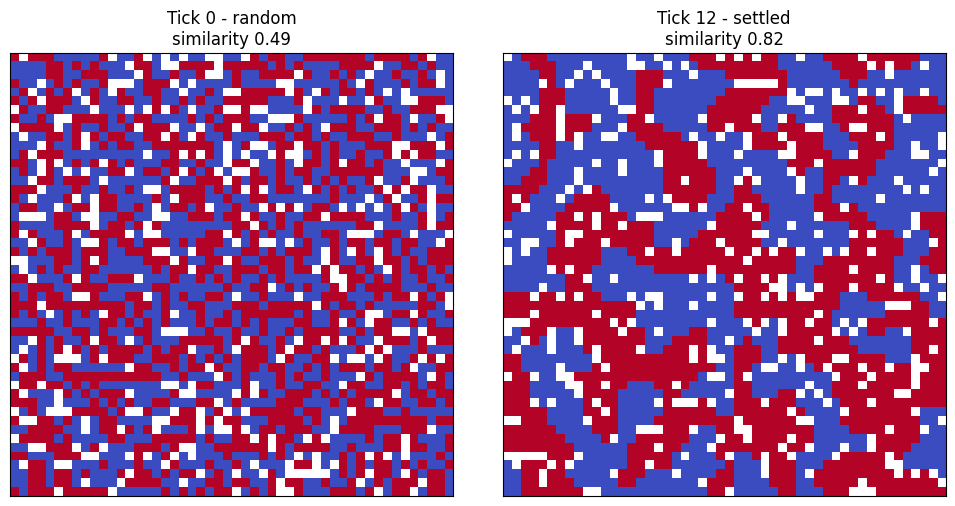

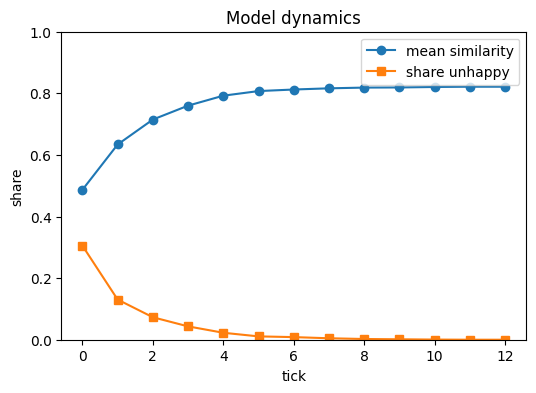

In [11]:
# before vs after, side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
cmap = plt.get_cmap("coolwarm").copy(); cmap.set_bad("white")
axes[0].imshow(np.ma.masked_invalid(initial_grid), cmap=cmap, vmin=0, vmax=N_GROUPS - 1)
axes[0].set_title(f"Tick 0 - random\nsimilarity {history[0]['mean_similarity']:.2f}")
axes[0].set_xticks([]); axes[0].set_yticks([])
plot_grid(model, f"Tick {history[-1]['tick']} - settled\n"
                 f"similarity {history[-1]['mean_similarity']:.2f}", ax=axes[1])
plt.tight_layout(); plt.show()

plot_history(model)
plt.show()

# Every household was happy to be a MINORITY (40% like them), yet the city ended up clustered.
# That clustering is emergent: it lives in the grid, not in anyone's preferences.

### 7. Where to take this next
Each of these is a small, self-contained change. If you need a starting idea, pick one and try it!

**Change the agent rule** (edit `Household`)

**Change the environment** (edit `Neighbourhood`)

**Change the initial conditions** (edit `create_households` / `place_households`)

**Change the model** (edit `SegregationModel`)

**Good practice once you outgrow one notebook**
- Split into `agents.py`, `environment.py`, `model.py`, `analysis.py`, and import them here.
- Keep parameters in a single dictionary or config file rather than scattered globals.
- Always pass an explicit `seed` so every result you show can be reproduced exactly.
- Run every experiment several times and report the spread, not just the mean.